# 1. Imports

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pykitti
from pathlib import Path
import torch
import json
import os

# Load KITTI
base = Path.home() / 'SensorTrust' / 'datasets' / 'kitti'
data = pykitti.raw(base_path=str(base), date='2011_09_26', drive='0009')

from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies
from src.features.normalization import MotionNormalizer
from src.features.f1_kinematic import extract_all_f1_features
from src.features.f2_scene import compute_f2
from src.features.gmis import compute_gmis
from src.attacks.gps_attack import gps_speed_ramp, gps_step_offset
from src.attacks.imu_attack import attack_imu_proxies
from src.attacks.lidar_attack import inject_phantom_sequence
from src.attacks.camera_attack import gaussian_noise as cam_gaussian_noise
from src.anomaly.sequence_dataset import create_sequences
from src.anomaly.lstm_autoencoder import LSTMAutoencoder
from src.anomaly.ema import EMABaseline
from src.anomaly.mahalanobis import MahalanobisDetector
from src.anomaly.detector import detect_anomalies
from sklearn.metrics import precision_score, recall_score, f1_score
from src.graph.disagreement_graph import build_disagreement_graph
from src.graph.trust_score import compute_trust_scores, compute_node_inconsistency
from src.graph.ranking import rank_sensors

print("✅ All imports successful")
print(f"Frames: {len(data.oxts)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
✅ All imports successful
Frames: 447


# 2. Extract clean proxies

In [2]:
dt = 0.1035

gps_clean = extract_all_gps_proxies(data.oxts, dt=dt)
imu_clean = extract_all_imu_proxies(data.oxts, dt=dt)

camera_frames = [np.array(f) for f in list(data.cam2)]
cam_clean = extract_all_camera_proxies(camera_frames)

velo_scans = list(data.velo)
lidar_clean = extract_all_lidar_proxies(velo_scans, data.oxts[:len(velo_scans)])

print("✅ Clean proxies extracted")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
✅ Clean proxies extracted


# 3. Fit normalizer:

In [3]:
normalizer = MotionNormalizer()
normalizer.fit(gps_clean, imu_clean, cam_clean, lidar_clean)

z_clean = normalizer.transform(gps_clean, imu_clean, cam_clean, lidar_clean)

print("✅ Normalizer fitted")

Normalization parameters fitted:
  gps_delta_v         : μ= -0.1212, σ=  0.4548
  gps_heading_rate    : μ=  0.0423, σ=  1.7530
  imu_delta_v         : μ= -0.1656, σ=  0.4658
  imu_yaw_rate        : μ=  0.0279, σ=  0.1016
  camera_flow         : μ= 11.7695, σ=  5.5256
  lidar_icp           : μ=  0.1131, σ=  0.0318
✅ Normalizer fitted


# 4. Compute Clean features

In [4]:
f1_clean = extract_all_f1_features(z=z_clean, gps_speed=gps_clean['speed'])['f1']

min_len_f2 = min(len(z_clean['gps_delta_v']), len(z_clean['lidar_icp']))
f2_clean = compute_f2(z_clean['gps_delta_v'][:min_len_f2], z_clean['lidar_icp'][:min_len_f2])

min_len_gmis = min(len(z_clean['gps_delta_v']), len(z_clean['imu_delta_v']), 
                   len(z_clean['lidar_icp']), len(z_clean['camera_flow']))
gmis_clean = compute_gmis(z_clean['gps_delta_v'][:min_len_gmis],
                          z_clean['imu_delta_v'][:min_len_gmis],
                          z_clean['lidar_icp'][:min_len_gmis],
                          z_clean['camera_flow'][:min_len_gmis])

CLEAN_F1 = np.nanmean(f1_clean)
CLEAN_F2 = np.nanmean(f2_clean)
CLEAN_GMIS = np.nanmean(gmis_clean)

print("✅ Clean features computed")
print(f"F1:   mean={CLEAN_F1:.4f}")
print(f"F2:   mean={CLEAN_F2:.4f}")
print(f"GMIS: mean={CLEAN_GMIS:.4f}")

✅ Clean features computed
F1:   mean=0.5598
F2:   mean=0.9053
GMIS: mean=0.8221


# Helper function:

In [5]:
def run_attack(name, gps_data, imu_data, cam_data, lidar_data):
    """Run full pipeline and return BOTH means AND full feature arrays."""
    if isinstance(gps_data, dict) and 'delta_v' in gps_data:
        gps_p = gps_data
    else:
        gps_p = extract_all_gps_proxies(gps_data, dt=dt)
    
    if isinstance(imu_data, dict) and 'delta_v' in imu_data:
        imu_p = imu_data
    else:
        imu_p = extract_all_imu_proxies(imu_data, dt=dt)
    
    if isinstance(cam_data, dict) and 'flow_magnitude' in cam_data:
        cam_p = cam_data
    else:
        cam_p = extract_all_camera_proxies(cam_data)
    
    if isinstance(lidar_data, dict) and 'icp_residual' in lidar_data:
        lidar_p = lidar_data
    else:
        lidar_p = extract_all_lidar_proxies(lidar_data, data.oxts[:len(lidar_data)])
    
    z = normalizer.transform(gps_p, imu_p, cam_p, lidar_p)
    mf2 = min(len(z['gps_delta_v']), len(z['lidar_icp']))
    mg = min(len(z['gps_delta_v']), len(z['imu_delta_v']), len(z['lidar_icp']), len(z['camera_flow']))
    
    f1 = extract_all_f1_features(z=z, gps_speed=gps_p['speed'])['f1']
    f2 = compute_f2(z['gps_delta_v'][:mf2], z['lidar_icp'][:mf2])
    gmis = compute_gmis(z['gps_delta_v'][:mg], z['imu_delta_v'][:mg],
                         z['lidar_icp'][:mg], z['camera_flow'][:mg])
    
    return {
        'name': name,
        'F1': np.nanmean(f1), 'F2': np.nanmean(f2), 'GMIS': np.nanmean(gmis),
        'F1_max': np.nanmax(f1), 'F2_max': np.nanmax(f2), 'GMIS_max': np.nanmax(gmis),
        'f1': f1, 'f2': f2, 'gmis': gmis  # ← NEW: full arrays
    }

print("✅ Helper function updated (now returns full feature arrays)")

✅ Helper function updated (now returns full feature arrays)


# 5. Attacks

## 1. GPS speed Ramp attack

In [6]:
gps_ramp_data, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
gps_ramp_result = run_attack('GPS Ramp', gps_ramp_data, data.oxts, camera_frames, velo_scans)

print("=== GPS SPEED RAMP ===")
print(f"F1:   {CLEAN_F1:.4f} → {gps_ramp_result['F1']:.4f}  ({gps_ramp_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {gps_ramp_result['F2']:.4f}  ({gps_ramp_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {gps_ramp_result['GMIS']:.4f}  ({gps_ramp_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== GPS SPEED RAMP ===
F1:   0.5598 → 5.3510  (9.6x)
F2:   0.9053 → 5.7256  (6.3x)
GMIS: 0.8221 → 4.3453  (5.3x)


## 2. GPS step Offset Attack

In [7]:
gps_step_data, _ = gps_step_offset(data.oxts, start_frame=200, lat_offset=0.005, lon_offset=0.005, duration=50)
gps_step_result = run_attack('GPS Step', gps_step_data, data.oxts, camera_frames, velo_scans)

print("=== GPS STEP OFFSET ===")
print(f"F1:   {CLEAN_F1:.4f} → {gps_step_result['F1']:.4f}  ({gps_step_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {gps_step_result['F2']:.4f}  ({gps_step_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {gps_step_result['GMIS']:.4f}  ({gps_step_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== GPS STEP OFFSET ===
F1:   0.5598 → 0.6290  (1.1x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.8221  (1.0x)


## 3. IMU Constant Bias Attack

In [8]:
imu_bias_data = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
imu_bias_result = run_attack('IMU Bias', gps_clean, imu_bias_data, camera_frames, velo_scans)

print("=== IMU CONSTANT BIAS ===")
print(f"F1:   {CLEAN_F1:.4f} → {imu_bias_result['F1']:.4f}  ({imu_bias_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {imu_bias_result['F2']:.4f}  ({imu_bias_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {imu_bias_result['GMIS']:.4f}  ({imu_bias_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== IMU CONSTANT BIAS ===
F1:   0.5598 → 5.1456  (9.2x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 1.1458  (1.4x)


## 4. IMU Gaussian Noise Attack

In [9]:
imu_noise_data = attack_imu_proxies(imu_clean, attack_type='noise', std=0.3)
imu_noise_result = run_attack('IMU Noise', gps_clean, imu_noise_data, camera_frames, velo_scans)

print("=== IMU GAUSSIAN NOISE ===")
print(f"F1:   {CLEAN_F1:.4f} → {imu_noise_result['F1']:.4f}  ({imu_noise_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {imu_noise_result['F2']:.4f}  ({imu_noise_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {imu_noise_result['GMIS']:.4f}  ({imu_noise_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== IMU GAUSSIAN NOISE ===
F1:   0.5598 → 2.4444  (4.4x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.9519  (1.2x)


## 5. IMU Burst Noise Attack

In [10]:
imu_burst_data = attack_imu_proxies(imu_clean, attack_type='burst', start_frame=200, duration=30, amplitude=1.0)
imu_burst_result = run_attack('IMU Burst', gps_clean, imu_burst_data, camera_frames, velo_scans)

print("=== IMU BURST NOISE ===")
print(f"F1:   {CLEAN_F1:.4f} → {imu_burst_result['F1']:.4f}  ({imu_burst_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {imu_burst_result['F2']:.4f}  ({imu_burst_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {imu_burst_result['GMIS']:.4f}  ({imu_burst_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== IMU BURST NOISE ===
F1:   0.5598 → 1.0146  (1.8x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.8708  (1.1x)


## 6. LiDAR Phantom Attack

In [11]:
lidar_phantom_data, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
lidar_phantom_result = run_attack('LiDAR Phantom', gps_clean, imu_clean, camera_frames, lidar_phantom_data)

print("=== LIDAR PHANTOM INJECTION ===")
print(f"F1:   {CLEAN_F1:.4f} → {lidar_phantom_result['F1']:.4f}  ({lidar_phantom_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {lidar_phantom_result['F2']:.4f}  ({lidar_phantom_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {lidar_phantom_result['GMIS']:.4f}  ({lidar_phantom_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== LIDAR PHANTOM INJECTION ===
F1:   0.5598 → 0.5598  (1.0x)
F2:   0.9053 → 1.5024  (1.7x)
GMIS: 0.8221 → 1.2009  (1.5x)


## 7. Camera Gaussian Noise Attack

In [12]:
frames_noisy = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
cam_noise_result = run_attack('Camera Noise', gps_clean, imu_clean, frames_noisy, velo_scans)

print("=== CAMERA GAUSSIAN NOISE ===")
print(f"F1:   {CLEAN_F1:.4f} → {cam_noise_result['F1']:.4f}  ({cam_noise_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {cam_noise_result['F2']:.4f}  ({cam_noise_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {cam_noise_result['GMIS']:.4f}  ({cam_noise_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== CAMERA GAUSSIAN NOISE ===
F1:   0.5598 → 0.5598  (1.0x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 0.8858  (1.1x)


## 8. Coordinated GPS + IMU Attack

In [13]:
gps_coord1, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=1.5, duration=50)
imu_coord1 = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.3)
coord_gps_imu_result = run_attack('Coord GPS+IMU', gps_coord1, imu_coord1, camera_frames, velo_scans)

print("=== COORDINATED GPS + .} → {coord_gps_imu_result['F2']:.4f}  ({coord_gps_imu_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_gps_imu_result['GMIS']:.4f}  ({coord_gps_imu_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED GPS + .} → {coord_gps_imu_result['F2']:.4f}  ({coord_gps_imu_result['F2']/CLEAN_F2:.1f}x)
GMIS: 0.8221 → 3.5161  (4.3x)


## 9. Coordinated GPS + Camera Attack

In [14]:
gps_coord2, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
frames_coord = [cam_gaussian_noise(np.array(f), std=20) for f in camera_frames]
coord_gps_cam_result = run_attack('Coord GPS+Cam', gps_coord2, imu_clean, frames_coord, velo_scans)

print("=== COORDINATED GPS + CAMERA ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_gps_cam_result['F1']:.4f}  ({coord_gps_cam_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_gps_cam_result['F2']:.4f}  ({coord_gps_cam_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_gps_cam_result['GMIS']:.4f}  ({coord_gps_cam_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED GPS + CAMERA ===
F1:   0.5598 → 5.3510  (9.6x)
F2:   0.9053 → 5.7256  (6.3x)
GMIS: 0.8221 → 4.3954  (5.3x)


## 10. Coordinated GPS + LiDAR Attack

In [15]:
gps_coord3, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
lidar_coord, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
coord_gps_lidar_result = run_attack('Coord GPS+LiDAR', gps_coord3, imu_clean, camera_frames, lidar_coord)

print("=== COORDINATED GPS + LiDAR ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_gps_lidar_result['F1']:.4f}  ({coord_gps_lidar_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_gps_lidar_result['F2']:.4f}  ({coord_gps_lidar_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_gps_lidar_result['GMIS']:.4f}  ({coord_gps_lidar_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED GPS + LiDAR ===
F1:   0.5598 → 5.3510  (9.6x)
F2:   0.9053 → 6.3226  (7.0x)
GMIS: 0.8221 → 4.7241  (5.7x)


## 11. Coordinated IMU + LiDAR

In [16]:
imu_coord_il = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
lidar_coord_il, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
coord_imu_lidar_result = run_attack('Coord IMU+LiDAR', gps_clean, imu_coord_il, camera_frames, lidar_coord_il)

print("=== COORDINATED IMU + LiDAR ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_imu_lidar_result['F1']:.4f}  ({coord_imu_lidar_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_imu_lidar_result['F2']:.4f}  ({coord_imu_lidar_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_imu_lidar_result['GMIS']:.4f}  ({coord_imu_lidar_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED IMU + LiDAR ===
F1:   0.5598 → 5.1456  (9.2x)
F2:   0.9053 → 1.5021  (1.7x)
GMIS: 0.8221 → 1.4739  (1.8x)


## 12. Coordinated IMU And Camera

In [17]:
imu_coord_ic = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
frames_coord_ic = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
coord_imu_cam_result = run_attack('Coord IMU+Cam', gps_clean, imu_coord_ic, frames_coord_ic, velo_scans)

print("=== COORDINATED IMU + CAMERA ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_imu_cam_result['F1']:.4f}  ({coord_imu_cam_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_imu_cam_result['F2']:.4f}  ({coord_imu_cam_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_imu_cam_result['GMIS']:.4f}  ({coord_imu_cam_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED IMU + CAMERA ===
F1:   0.5598 → 5.1456  (9.2x)
F2:   0.9053 → 0.9053  (1.0x)
GMIS: 0.8221 → 1.1522  (1.4x)


## 13. Coordinated LiDAR amd Camera

In [18]:
lidar_coord_lc, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
frames_coord_lc = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
coord_lidar_cam_result = run_attack('Coord LiDAR+Cam', gps_clean, imu_clean, frames_coord_lc, lidar_coord_lc)

print("=== COORDINATED LiDAR + CAMERA ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_lidar_cam_result['F1']:.4f}  ({coord_lidar_cam_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_lidar_cam_result['F2']:.4f}  ({coord_lidar_cam_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_lidar_cam_result['GMIS']:.4f}  ({coord_lidar_cam_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== COORDINATED LiDAR + CAMERA ===
F1:   0.5598 → 0.5598  (1.0x)
F2:   0.9053 → 1.5024  (1.7x)
GMIS: 0.8221 → 1.2347  (1.5x)


## 14. All four sensors:

In [19]:
gps_all, _ = gps_speed_ramp(data.oxts, start_frame=200, ramp_rate=2.0, duration=50)
imu_all = attack_imu_proxies(imu_clean, attack_type='bias', bias=0.5)
lidar_all, _ = inject_phantom_sequence(velo_scans, start_frame=100, n_points=50000, distance=3.0, duration=100)
frames_all = [cam_gaussian_noise(np.array(f), std=25) for f in camera_frames]
coord_all_result = run_attack('ALL FOUR', gps_all, imu_all, frames_all, lidar_all)

print("=== ALL FOUR SENSORS ATTACKED ===")
print(f"F1:   {CLEAN_F1:.4f} → {coord_all_result['F1']:.4f}  ({coord_all_result['F1']/CLEAN_F1:.1f}x)")
print(f"F2:   {CLEAN_F2:.4f} → {coord_all_result['F2']:.4f}  ({coord_all_result['F2']/CLEAN_F2:.1f}x)")
print(f"GMIS: {CLEAN_GMIS:.4f} → {coord_all_result['GMIS']:.4f}  ({coord_all_result['GMIS']/CLEAN_GMIS:.1f}x)")

Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
=== ALL FOUR SENSORS ATTACKED ===
F1:   0.5598 → 9.7646  (17.4x)
F2:   0.9053 → 6.3226  (7.0x)
GMIS: 0.8221 → 4.8810  (5.9x)


# 6. Results Summary

In [20]:
all_results = {
    'Clean':              {'F1': CLEAN_F1, 'F2': CLEAN_F2, 'GMIS': CLEAN_GMIS},
    'GPS Ramp':           gps_ramp_result,
    'GPS Step':           gps_step_result,
    'IMU Bias':           imu_bias_result,
    'IMU Noise':          imu_noise_result,
    'IMU Burst':          imu_burst_result,
    'LiDAR Phantom':      lidar_phantom_result,
    'Camera Noise':       cam_noise_result,
    'Coord GPS+IMU':      coord_gps_imu_result,
    'Coord GPS+Cam':      coord_gps_cam_result,
    'Coord GPS+LiDAR':    coord_gps_lidar_result,
    'Coord IMU+LiDAR':    coord_imu_lidar_result,
    'Coord IMU+Cam':      coord_imu_cam_result,
    'Coord LiDAR+Cam':    coord_lidar_cam_result,
    'ALL FOUR':           coord_all_result,
}

print("\n" + "=" * 78)
print("COMPLETE ATTACK EVALUATION")
print("=" * 78)
print(f"{'Attack':<22} {'F1':>8} {'F2':>8} {'GMIS':>8}  {'F1x':>6} {'F2x':>6} {'GMISx':>6}  {'Detected?':>10}")
print("-" * 78)

for name, r in all_results.items():
    f1_r = r['F1'] / CLEAN_F1 if CLEAN_F1 > 0 else 0
    f2_r = r['F2'] / CLEAN_F2 if CLEAN_F2 > 0 else 0
    g_r = r['GMIS'] / CLEAN_GMIS if CLEAN_GMIS > 0 else 0
    
    detected = f1_r > 3 or f2_r > 3 or g_r > 3
    status = '✅ YES' if detected else '❌ NO'
    
    print(f"{name:<22} {r['F1']:8.4f} {r['F2']:8.4f} {r['GMIS']:8.4f}  {f1_r:5.1f}x {f2_r:5.1f}x {g_r:5.1f}x  {status:>10}")

print("-" * 78)
print("Detection = at least one feature > 3x clean baseline")


COMPLETE ATTACK EVALUATION
Attack                       F1       F2     GMIS     F1x    F2x  GMISx   Detected?
------------------------------------------------------------------------------
Clean                    0.5598   0.9053   0.8221    1.0x   1.0x   1.0x        ❌ NO
GPS Ramp                 5.3510   5.7256   4.3453    9.6x   6.3x   5.3x       ✅ YES
GPS Step                 0.6290   0.9053   0.8221    1.1x   1.0x   1.0x        ❌ NO
IMU Bias                 5.1456   0.9053   1.1458    9.2x   1.0x   1.4x       ✅ YES
IMU Noise                2.4444   0.9053   0.9519    4.4x   1.0x   1.2x       ✅ YES
IMU Burst                1.0146   0.9053   0.8708    1.8x   1.0x   1.1x        ❌ NO
LiDAR Phantom            0.5598   1.5024   1.2009    1.0x   1.7x   1.5x        ❌ NO
Camera Noise             0.5598   0.9053   0.8858    1.0x   1.0x   1.1x        ❌ NO
Coord GPS+IMU            6.5954   4.5180   3.5161   11.8x   5.0x   4.3x       ✅ YES
Coord GPS+Cam            5.3510   5.7256   4.3954    

## Bar Chart

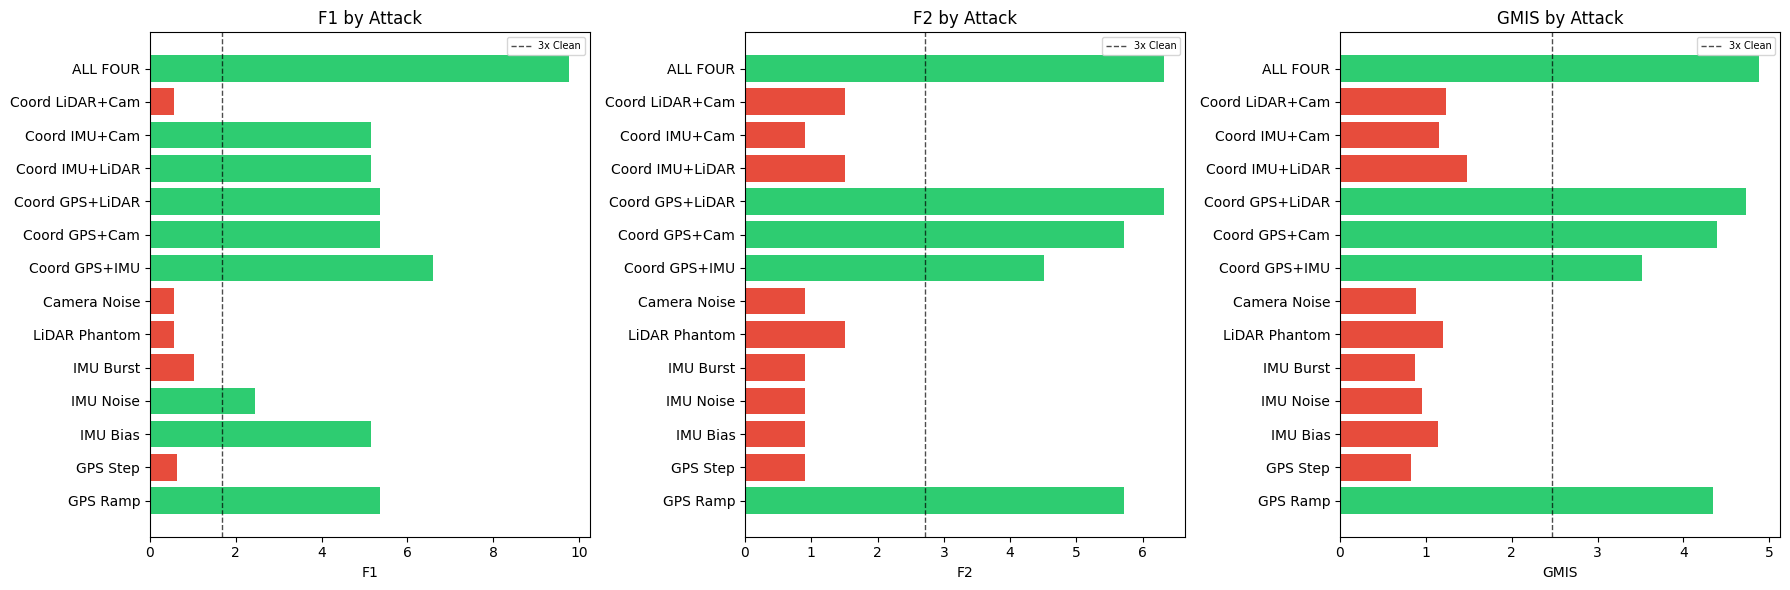

In [21]:
attack_names = [n for n in all_results.keys() if n != 'Clean']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feat, clean_val in zip(axes, ['F1', 'F2', 'GMIS'], [CLEAN_F1, CLEAN_F2, CLEAN_GMIS]):
    values = [all_results[n][feat] for n in attack_names]
    colors_list = ['#2ecc71' if v / clean_val > 3 else '#e74c3c' for v in values]
    
    ax.barh(attack_names, values, color=colors_list)
    ax.axvline(x=clean_val * 3, color='black', linestyle='--', linewidth=1, alpha=0.7, label='3x Clean')
    ax.set_xlabel(feat)
    ax.set_title(f'{feat} by Attack')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# 7. LSTM detection

## LSTM Autoencoder detection cell 

In [22]:
import torch
import json
from src.anomaly.sequence_dataset import create_sequences
from src.anomaly.lstm_autoencoder import LSTMAutoencoder

# Load trained model and threshold
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMAutoencoder(n_features=3, hidden_size=64, latent_size=32).to(device)
model.load_state_dict(torch.load('../src/models/lstm_autoencoder.pt', map_location=device))
model.eval()

with open('../src/models/threshold.json', 'r') as f:
    threshold = json.load(f)['threshold']

print(f"Model loaded. Threshold: {threshold:.4f}")

def detect_with_autoencoder(f1_arr, f2_arr, gmis_arr, seq_len=20):
    """Run LSTM autoencoder detection on feature arrays."""
    min_len = min(len(f1_arr), len(f2_arr), len(gmis_arr))
    X = np.column_stack([f1_arr[:min_len], f2_arr[:min_len], gmis_arr[:min_len]])
    X = X[~np.isnan(X).any(axis=1)]
    
    if len(X) < seq_len:
        return None, None, None
    
    X_seq = create_sequences(X, seq_len=seq_len)
    X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)
    
    errors = []
    with torch.no_grad():
        for i in range(len(X_tensor)):
            x = X_tensor[i].unsqueeze(0)
            recon = model(x)
            mse = torch.mean((x - recon) ** 2).item()
            errors.append(mse)
    
    errors = np.array(errors)
    detected = errors > threshold
    detection_rate = np.sum(detected) / len(detected) * 100
    
    return errors, detected, detection_rate

print("Detection function ready.")

Model loaded. Threshold: 1.0961
Detection function ready.


## Run Detection on all ATTACKS

In [23]:
print("\n" + "=" * 78)
print("LSTM AUTOENCODER DETECTION RESULTS")
print("=" * 78)
print(f"{'Attack':<22} {'Mean Error':>10} {'Max Error':>10} {'Detect Rate':>12} {'Detected?':>10}")
print("-" * 78)

for name, r in all_results.items():
    if name == 'Clean':
        continue
    
    errors, detected, rate = detect_with_autoencoder(r['f1'], r['f2'], r['gmis'])
    
    if errors is not None:
        mean_err = np.mean(errors)
        max_err = np.max(errors)
        status = '✅ YES' if rate > 50 else '❌ NO'
        print(f"{name:<22} {mean_err:10.4f} {max_err:10.4f} {rate:11.1f}% {status:>10}")
    else:
        print(f"{name:<22} {'N/A':>10} {'N/A':>10} {'N/A':>12} {'❌ NO DATA':>10}")

print("-" * 78)
print("Detection = >50% of sequences flagged")


LSTM AUTOENCODER DETECTION RESULTS
Attack                 Mean Error  Max Error  Detect Rate  Detected?
------------------------------------------------------------------------------
GPS Ramp                 504.8148  9782.6055        27.5%       ❌ NO
GPS Step                   1.0747     8.7713        24.4%       ❌ NO
IMU Bias                  10.9825    33.8508        97.8%      ✅ YES
IMU Noise                  3.5149     8.6530        94.0%      ✅ YES
IMU Burst                  4.7607    86.4126        20.1%       ❌ NO
LiDAR Phantom              2.0122    17.7942        34.9%       ❌ NO
Camera Noise               0.6999     5.5774        19.4%       ❌ NO
Coord GPS+IMU            295.2113  5607.7544        96.2%      ✅ YES
Coord GPS+Cam            504.7643  9783.3994        27.5%       ❌ NO
Coord GPS+LiDAR          506.1279  9782.6055        43.1%       ❌ NO
Coord IMU+LiDAR           12.4728    33.8508        97.8%      ✅ YES
Coord IMU+Cam             10.9805    33.8403        97.8%

## Plot Detection Comparision

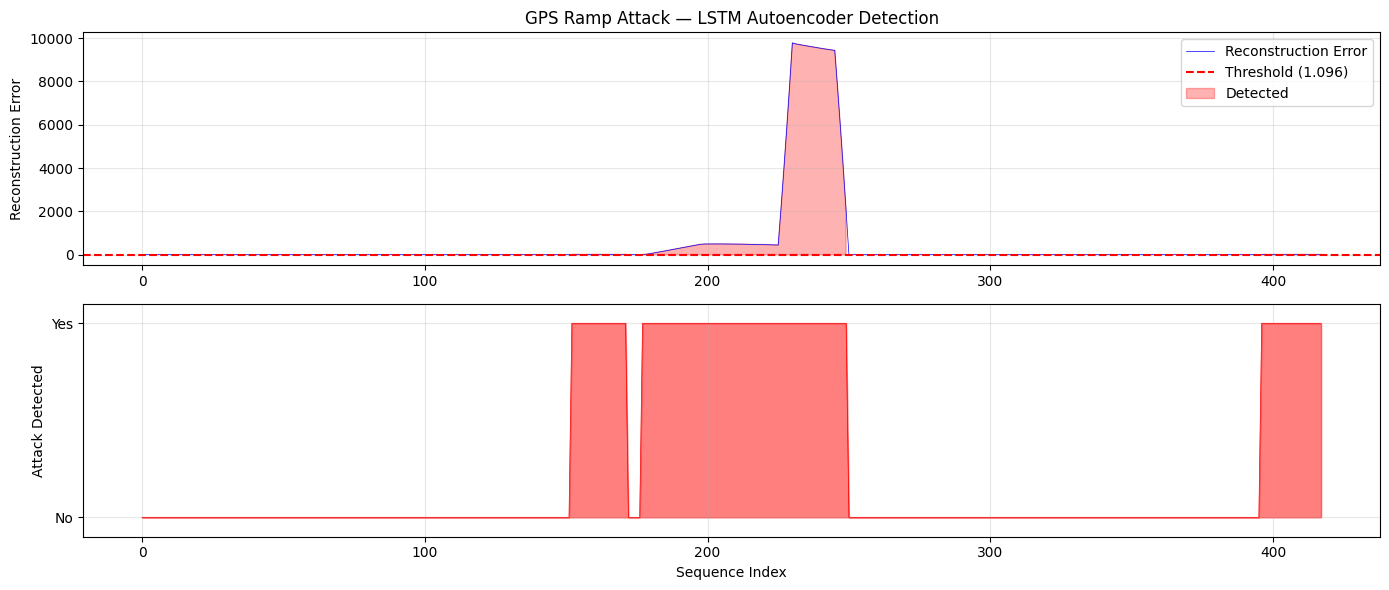

Detection rate: 27.5%
Mean error (attack): 504.8148
Mean error (clean): 0.7091
Ratio: 711.9x


In [24]:
# Pick a strong attack to visualize
errors, detected, rate = detect_with_autoencoder(
    gps_ramp_result['f1'], 
    gps_ramp_result['f2'], 
    gps_ramp_result['gmis']
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))

# Plot reconstruction error
ax1.plot(errors, 'b-', linewidth=0.5, label='Reconstruction Error')
ax1.axhline(y=threshold, color='r', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.3f})')
ax1.fill_between(range(len(errors)), 0, errors, where=(errors > threshold), 
                  color='red', alpha=0.3, label='Detected')
ax1.set_ylabel('Reconstruction Error')
ax1.set_title('GPS Ramp Attack — LSTM Autoencoder Detection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot detection binary
ax2.plot(detected.astype(int), 'r-', linewidth=0.5)
ax2.fill_between(range(len(detected)), 0, detected, color='red', alpha=0.5)
ax2.set_ylabel('Attack Detected')
ax2.set_xlabel('Sequence Index')
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['No', 'Yes'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Detection rate: {rate:.1f}%")
print(f"Mean error (attack): {np.mean(errors):.4f}")
print(f"Mean error (clean): 0.7091")
print(f"Ratio: {np.mean(errors)/0.7091:.1f}x")

# 8. Fit Mahalonobis on Clean data

In [25]:
mahal = MahalanobisDetector()
min_len = min(len(f1_clean), len(f2_clean), len(gmis_clean))
mahal.fit(f1_clean[:min_len], f2_clean[:min_len], gmis_clean[:min_len])
MAHAL_THRESHOLD = 3.0
print("Mahalanobis fitted on clean data")

Mahalanobis fitted on 437 samples
Mahalanobis fitted on clean data


# 12. Score all attacks

In [26]:
print("\n" + "=" * 78)
print("MAHALANOBIS DETECTION RESULTS")
print("=" * 78)
print(f"{'Attack':<22} {'Mean Score':>10} {'Max Score':>10} {'Detect Rate':>12} {'Detected?':>10}")
print("-" * 78)



for name, r in all_results.items():
    if name == 'Clean':
        continue

    min_len = min(len(r['f1']), len(r['f2']), len(r['gmis']))
    f1_a = r['f1'][:min_len]
    f2_a = r['f2'][:min_len]
    g_a  = r['gmis'][:min_len]

    # drop NaNs
    mask = ~(np.isnan(f1_a) | np.isnan(f2_a) | np.isnan(g_a))
    f1_a, f2_a, g_a = f1_a[mask], f2_a[mask], g_a[mask]

    scores  = mahal.score(f1_a, f2_a, g_a)
    alerts  = detect_anomalies(scores, threshold=MAHAL_THRESHOLD)

    valid   = ~np.isnan(scores)
    rate    = np.sum(alerts[valid]) / np.sum(valid) * 100
    status  = '✅ YES' if rate > 50 else '❌ NO'

    print(f"{name:<22} {np.nanmean(scores):10.4f} {np.nanmax(scores):10.4f} {rate:11.1f}% {status:>10}")

print("-" * 78)
print("Detection = >50% of frames exceed Mahalanobis distance threshold of 3.0")


MAHALANOBIS DETECTION RESULTS
Attack                 Mean Score  Max Score  Detect Rate  Detected?
------------------------------------------------------------------------------
GPS Ramp                   8.9225   348.0620        13.7%       ❌ NO
GPS Step                   1.5362    17.1966         6.9%       ❌ NO
IMU Bias                   6.1461    11.9513        92.9%      ✅ YES
IMU Noise                  3.1123    10.6819        44.4%       ❌ NO
IMU Burst                  2.0529    46.7112         8.2%       ❌ NO
LiDAR Phantom              1.8898    22.2408        16.7%       ❌ NO
Camera Noise               1.5924    10.0589        10.3%       ❌ NO
Coord GPS+IMU              8.9538   263.0968        83.3%      ✅ YES
Coord GPS+Cam              9.0552   348.1399        17.4%       ❌ NO
Coord GPS+LiDAR            9.3462   348.0620        24.0%       ❌ NO
Coord IMU+LiDAR            6.2881    21.8926        93.4%      ✅ YES
Coord IMU+Cam              6.1362    11.4380        92.9%     

# 13. Compare both detectors side by side:

In [27]:
print("\n" + "=" * 90)
print("DETECTOR COMPARISON: MAHALANOBIS vs LSTM AUTOENCODER")
print("=" * 90)
print(f"{'Attack':<22} {'Mahal Rate':>12} {'LSTM Rate':>12} {'Mahal':>8} {'LSTM':>8} {'Either':>8}")
print("-" * 90)

for name, r in all_results.items():
    if name == 'Clean':
        continue

    # mahalanobis
    min_len = min(len(r['f1']), len(r['f2']), len(r['gmis']))
    f1_a = r['f1'][:min_len]
    f2_a = r['f2'][:min_len]
    g_a  = r['gmis'][:min_len]
    mask = ~(np.isnan(f1_a) | np.isnan(f2_a) | np.isnan(g_a))
    scores = mahal.score(f1_a[mask], f2_a[mask], g_a[mask])
    alerts = detect_anomalies(scores, threshold=MAHAL_THRESHOLD)
    valid  = ~np.isnan(scores)
    mahal_rate = np.sum(alerts[valid]) / np.sum(valid) * 100

    # lstm
    errors, detected, lstm_rate = detect_with_autoencoder(r['f1'], r['f2'], r['gmis'])
    if lstm_rate is None:
        lstm_rate = 0.0

    mahal_det = '✅' if mahal_rate > 50 else '❌'
    lstm_det  = '✅' if lstm_rate  > 50 else '❌'
    either    = '✅' if (mahal_rate > 50 or lstm_rate > 50) else '❌'
# NOTE: This is an approximation using derived features as proxies
# for raw normalized signals. The real z-signal trust scores 
# (computed in the cell below using attack_proxy_map) are more 
# accurate but only available for 4 selected attacks due to 
# reprocessing cost. The approximated ranking is used for the 
# full 14-attack heatmap visualization.
    print(f"{name:<22} {mahal_rate:11.1f}% {lstm_rate:11.1f}% {mahal_det:>8} {lstm_det:>8} {either:>8}")

print("-" * 90)


DETECTOR COMPARISON: MAHALANOBIS vs LSTM AUTOENCODER
Attack                   Mahal Rate    LSTM Rate    Mahal     LSTM   Either
------------------------------------------------------------------------------------------
GPS Ramp                      13.7%        27.5%        ❌        ❌        ❌
GPS Step                       6.9%        24.4%        ❌        ❌        ❌
IMU Bias                      92.9%        97.8%        ✅        ✅        ✅
IMU Noise                     44.4%        94.0%        ❌        ✅        ✅
IMU Burst                      8.2%        20.1%        ❌        ❌        ❌
LiDAR Phantom                 16.7%        34.9%        ❌        ❌        ❌
Camera Noise                  10.3%        19.4%        ❌        ❌        ❌
Coord GPS+IMU                 83.3%        96.2%        ✅        ✅        ✅
Coord GPS+Cam                 17.4%        27.5%        ❌        ❌        ❌
Coord GPS+LiDAR               24.0%        43.1%        ❌        ❌        ❌
Coord IMU+LiDAR    

# 14. Precision / Recall / F1 per detector:

In [28]:
# ground truth: everything that isnt Clean is an attack
attack_names_only = [n for n in all_results if n != 'Clean']
y_true = np.ones(len(attack_names_only), dtype=int)

mahal_preds = []
lstm_preds  = []

for name in attack_names_only:
    r = all_results[name]

    # mahalanobis prediction
    min_len = min(len(r['f1']), len(r['f2']), len(r['gmis']))
    f1_a = r['f1'][:min_len]
    f2_a = r['f2'][:min_len]
    g_a  = r['gmis'][:min_len]
    mask = ~(np.isnan(f1_a) | np.isnan(f2_a) | np.isnan(g_a))
    scores = mahal.score(f1_a[mask], f2_a[mask], g_a[mask])
    alerts = detect_anomalies(scores, threshold=MAHAL_THRESHOLD)
    valid  = ~np.isnan(scores)
    mahal_rate = np.sum(alerts[valid]) / np.sum(valid) * 100
    mahal_preds.append(1 if mahal_rate > 50 else 0)

    # lstm prediction
    _, _, lstm_rate = detect_with_autoencoder(r['f1'], r['f2'], r['gmis'])
    lstm_preds.append(1 if (lstm_rate or 0) > 50 else 0)

mahal_preds = np.array(mahal_preds)
lstm_preds  = np.array(lstm_preds)
either_preds = ((mahal_preds + lstm_preds) > 0).astype(int)

print("\n" + "=" * 50)
print("DETECTION METRICS SUMMARY")
print("=" * 50)
for label, preds in [('Mahalanobis', mahal_preds), ('LSTM AE', lstm_preds), ('Either', either_preds)]:
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)
    f = f1_score(y_true, preds, zero_division=0)
    print(f"{label:<15}  Precision={p:.2f}  Recall={r:.2f}  F1={f:.2f}")


DETECTION METRICS SUMMARY
Mahalanobis      Precision=1.00  Recall=0.36  F1=0.53
LSTM AE          Precision=1.00  Recall=0.43  F1=0.60
Either           Precision=1.00  Recall=0.43  F1=0.60


# 15. ROC-style plot (detection rate vs threshold sweep):

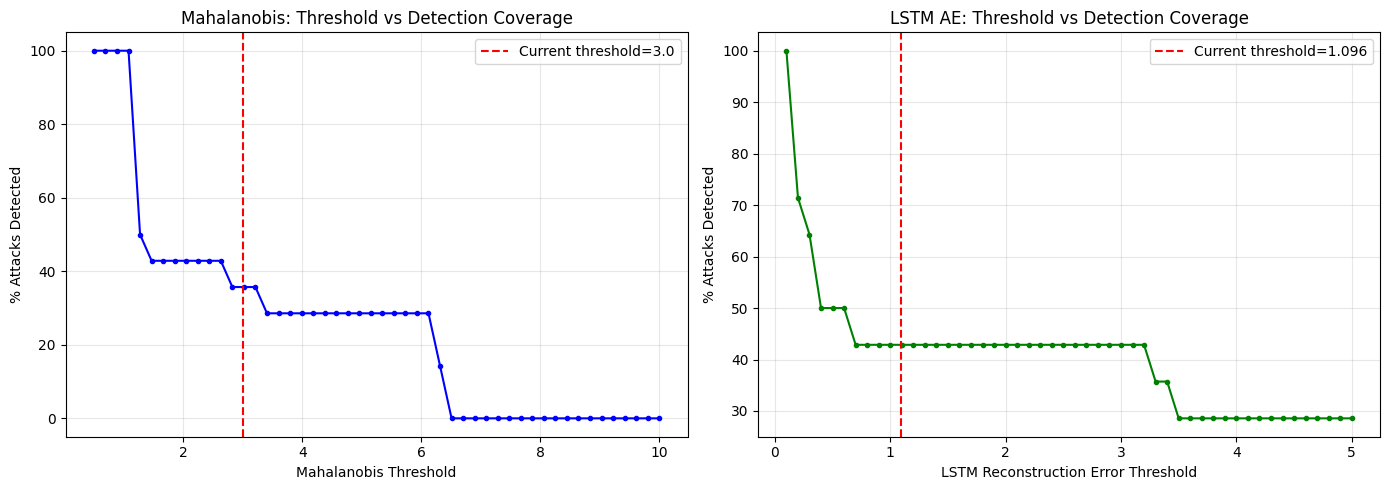

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

thresholds = np.linspace(0.5, 10, 50)
mahal_rates_by_thresh = []

for thresh in thresholds:
    detected_count = 0
    for name in attack_names_only:
        r = all_results[name]
        min_len = min(len(r['f1']), len(r['f2']), len(r['gmis']))
        f1_a = r['f1'][:min_len]; f2_a = r['f2'][:min_len]; g_a = r['gmis'][:min_len]
        mask = ~(np.isnan(f1_a) | np.isnan(f2_a) | np.isnan(g_a))
        scores = mahal.score(f1_a[mask], f2_a[mask], g_a[mask])
        valid = ~np.isnan(scores)
        rate = np.sum(scores[valid] > thresh) / np.sum(valid) * 100
        if rate > 50:
            detected_count += 1
    mahal_rates_by_thresh.append(detected_count / len(attack_names_only) * 100)

axes[0].plot(thresholds, mahal_rates_by_thresh, 'b-o', markersize=3)
axes[0].axvline(x=MAHAL_THRESHOLD, color='r', linestyle='--', label=f'Current threshold={MAHAL_THRESHOLD}')
axes[0].set_xlabel('Mahalanobis Threshold')
axes[0].set_ylabel('% Attacks Detected')
axes[0].set_title('Mahalanobis: Threshold vs Detection Coverage')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM threshold sweep
lstm_thresholds = np.linspace(0.1, 5.0, 50)
lstm_rates_by_thresh = []

for thresh in lstm_thresholds:
    detected_count = 0
    for name in attack_names_only:
        r = all_results[name]
        min_len = min(len(r['f1']), len(r['f2']), len(r['gmis']))
        X = np.column_stack([r['f1'][:min_len], r['f2'][:min_len], r['gmis'][:min_len]])
        X = X[~np.isnan(X).any(axis=1)]
        if len(X) < 20:
            continue
        X_seq = create_sequences(X, seq_len=20)
        X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)
        errors = []
        with torch.no_grad():
            for i in range(len(X_tensor)):
                x = X_tensor[i].unsqueeze(0)
                recon = model(x)
                errors.append(torch.mean((x - recon) ** 2).item())
        errors = np.array(errors)
        rate = np.sum(errors > thresh) / len(errors) * 100
        if rate > 50:
            detected_count += 1
    lstm_rates_by_thresh.append(detected_count / len(attack_names_only) * 100)

axes[1].plot(lstm_thresholds, lstm_rates_by_thresh, 'g-o', markersize=3)
axes[1].axvline(x=threshold, color='r', linestyle='--', label=f'Current threshold={threshold:.3f}')
axes[1].set_xlabel('LSTM Reconstruction Error Threshold')
axes[1].set_ylabel('% Attacks Detected')
axes[1].set_title('LSTM AE: Threshold vs Detection Coverage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# 16. Trust Score and suspicion Ranking

In [30]:
def run_trust_scoring(z):
    """Given normalized signals z, compute trust scores and ranking."""
    min_len = min(len(z['gps_delta_v']), len(z['imu_delta_v']), 
                  len(z['lidar_icp']), len(z['camera_flow']))
    
    z_gps    = z['gps_delta_v'][:min_len]
    z_imu    = z['imu_delta_v'][:min_len]
    z_lidar  = z['lidar_icp'][:min_len]
    z_camera = z['camera_flow'][:min_len]

    graph         = build_disagreement_graph(z_gps, z_imu, z_lidar, z_camera)
    inconsistency = compute_node_inconsistency(graph)
    trust         = compute_trust_scores(inconsistency)
    ranking       = rank_sensors(inconsistency)
    
    return trust, ranking

print("=== TRUST SCORES AND SUSPICION RANKING PER ATTACK ===\n")
print(f"{'Attack':<22} {'#1 Suspect':>12} {'#2 Suspect':>12} {'#3':>10} {'#4':>10}")
print("-" * 70)

trust_results = {}
attack_names_only = [n for n in all_results if n != 'Clean']

# real z signal map — uses actual normalizer output for each attack
real_z_map = {
    'GPS Ramp':       normalizer.transform(extract_all_gps_proxies(gps_ramp_data, dt=dt), imu_clean, cam_clean, lidar_clean),
    'GPS Step':       normalizer.transform(extract_all_gps_proxies(gps_step_data, dt=dt), imu_clean, cam_clean, lidar_clean),
    'IMU Bias':       normalizer.transform(gps_clean, imu_bias_data, cam_clean, lidar_clean),
    'IMU Noise':      normalizer.transform(gps_clean, imu_noise_data, cam_clean, lidar_clean),
    'IMU Burst':      normalizer.transform(gps_clean, imu_burst_data, cam_clean, lidar_clean),
    'LiDAR Phantom':  normalizer.transform(gps_clean, imu_clean, cam_clean, extract_all_lidar_proxies(lidar_phantom_data, data.oxts[:len(lidar_phantom_data)])),
    'Camera Noise':   normalizer.transform(gps_clean, imu_clean, extract_all_camera_proxies(frames_noisy), lidar_clean),
    'Coord GPS+IMU':  normalizer.transform(extract_all_gps_proxies(gps_coord1, dt=dt), imu_coord1, cam_clean, lidar_clean),
    'Coord GPS+Cam':  normalizer.transform(extract_all_gps_proxies(gps_coord2, dt=dt), imu_clean, extract_all_camera_proxies(frames_coord), lidar_clean),
    'Coord GPS+LiDAR': normalizer.transform(extract_all_gps_proxies(gps_coord3, dt=dt), imu_clean, cam_clean, extract_all_lidar_proxies(lidar_coord, data.oxts[:len(lidar_coord)])),
    'Coord IMU+LiDAR': normalizer.transform(gps_clean, imu_coord_il, cam_clean, extract_all_lidar_proxies(lidar_coord_il, data.oxts[:len(lidar_coord_il)])),
    'Coord IMU+Cam':  normalizer.transform(gps_clean, imu_coord_ic, extract_all_camera_proxies(frames_coord_ic), lidar_clean),
    'Coord LiDAR+Cam': normalizer.transform(gps_clean, imu_clean, extract_all_camera_proxies(frames_coord_lc), extract_all_lidar_proxies(lidar_coord_lc, data.oxts[:len(lidar_coord_lc)])),
    'ALL FOUR':       normalizer.transform(extract_all_gps_proxies(gps_all, dt=dt), imu_all, extract_all_camera_proxies(frames_all), extract_all_lidar_proxies(lidar_all, data.oxts[:len(lidar_all)])),
}

print("=== CONSISTENCY SCORES AND SUSPICION RANKING PER ATTACK ===\n")
print(f"{'Attack':<22} {'#1 Suspect':>12} {'#2 Suspect':>12} {'#3':>10} {'#4':>10}")
print("-" * 70)

for name in attack_names_only:
    z = real_z_map[name]
    trust, ranking = run_trust_scoring(z)
    trust_results[name] = {'trust': trust, 'ranking': ranking}
    sensors_ranked = [s for s, _ in ranking]
    print(f"{name:<22} {sensors_ranked[0]:>12} {sensors_ranked[1]:>12} {sensors_ranked[2]:>10} {sensors_ranked[3]:>10}")

print("-" * 70)

=== TRUST SCORES AND SUSPICION RANKING PER ATTACK ===

Attack                   #1 Suspect   #2 Suspect         #3         #4
----------------------------------------------------------------------
Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240/443
Processing scan 260/443
Processing scan 280/443
Processing scan 300/443
Processing scan 320/443
Processing scan 340/443
Processing scan 360/443
Processing scan 380/443
Processing scan 400/443
Processing scan 420/443
Processing scan 440/443
Processing scan 20/443
Processing scan 40/443
Processing scan 60/443
Processing scan 80/443
Processing scan 100/443
Processing scan 120/443
Processing scan 140/443
Processing scan 160/443
Processing scan 180/443
Processing scan 200/443
Processing scan 220/443
Processing scan 240

In [ ]:
attack_proxy_map = {
    'GPS Ramp'        : (gps_ramp_data,   data.oxts,    camera_frames,  velo_scans),
    'IMU Bias'        : (gps_clean,        imu_bias_data, camera_frames, velo_scans),
    'Coord GPS+IMU'   : (gps_coord1,       imu_coord1,   camera_frames,  velo_scans),
    'ALL FOUR'        : (gps_all,          imu_all,      frames_all,     lidar_all),
}

print("=== TRUST SCORES (clean z signals) ===\n")
print(f"{'Attack':<22} {'GPS trust':>10} {'IMU trust':>10} {'LiDAR trust':>12} {'Cam trust':>10} {'Top Suspect':>12}")
print("-" * 80)

for name, (gps_d, imu_d, cam_d, lidar_d) in attack_proxy_map.items():
    z = normalizer.transform(
        extract_all_gps_proxies(gps_d, dt=dt) if not isinstance(gps_d, dict) else gps_d,
        extract_all_imu_proxies(imu_d, dt=dt) if not isinstance(imu_d, dict) else imu_d,
        extract_all_camera_proxies(cam_d) if not isinstance(cam_d, dict) else cam_d,
        extract_all_lidar_proxies(lidar_d, data.oxts[:len(lidar_d)]) if not isinstance(lidar_d, dict) else lidar_d,
    )
    trust, ranking = run_trust_scoring(z)
    top = ranking[0][0]
    print(f"{name:<22} {trust['gps']:10.4f} {trust['imu']:10.4f} {trust['lidar']:12.4f} {trust['camera']:10.4f} {top:>12}")

print("-" * 80)
print("Lower trust = higher suspicion")

=== TRUST SCORES (clean z signals) ===

Attack                  GPS trust  IMU trust  LiDAR trust  Cam trust  Top Suspect
--------------------------------------------------------------------------------


# improved trust interpretation

In [ ]:
print("\n" + "=" * 80)
print("COMBINED SUSPICION SCORING (Trust + LSTM + Temporal Persistence)")
print("=" * 80)
print(f"{'Attack':<22} {'Top Suspect (Graph)':>20} {'LSTM Confirms?':>15} {'Confidence':>12}")
print("-" * 80)

for name in attack_names_only:
    r  = all_results[name]
    tr = trust_results[name]
    
    # graph-based top suspect
    top_sensor = tr['ranking'][0][0]
    top_trust  = tr['trust'][top_sensor]
    
    # lstm anomaly rate as confirmation signal
    errors, _, lstm_rate = detect_with_autoencoder(r['f1'], r['f2'], r['gmis'])
    lstm_confirms = lstm_rate is not None and lstm_rate > 50
    
    # temporal persistence: what fraction of frames is inconsistency elevated
    min_len  = min(len(r['f1']), len(r['f2']), len(r['gmis']))
    f1_a     = np.nan_to_num(r['f1'][:min_len])
    f2_a     = np.nan_to_num(r['f2'][:min_len])
    gmis_a   = np.nan_to_num(r['gmis'][:min_len])
    
    f1_elevated   = np.mean(f1_a   > CLEAN_F1   * 2)
    f2_elevated   = np.mean(f2_a   > CLEAN_F2   * 2)
    gmis_elevated = np.mean(gmis_a > CLEAN_GMIS * 2)
    persistence   = float(np.mean([f1_elevated, f2_elevated, gmis_elevated]))
    
    # combined confidence: low trust + lstm confirms + temporal persistence
    graph_conf  = 1 - top_trust          # low trust → high graph confidence
    lstm_conf   = (lstm_rate or 0) / 100
    confidence  = float(0.4 * graph_conf + 0.4 * lstm_conf + 0.2 * persistence)
    
    confirm_str = '✅ YES' if lstm_confirms else '❌ NO'
    print(f"{name:<22} {top_sensor:>20} {confirm_str:>15} {confidence:>11.2f}")

print("-" * 80)
print("Confidence = 0.4×(graph inconsistency) + 0.4×(LSTM rate) + 0.2×(temporal persistence)")
print("Higher = more confident this is a real attack, not sensor drift")

# trust score decay over time for a single attack

In [ ]:
# trust score over time for GPS Ramp attack
sensors = ['gps', 'imu', 'lidar', 'camera']
colors = {'gps': '#e74c3c', 'imu': '#3498db', 'lidar': '#2ecc71', 'camera': '#f39c12'}
z_ramp = normalizer.transform(
    extract_all_gps_proxies(gps_ramp_data, dt=dt),
    imu_clean,
    cam_clean,
    lidar_clean
)

min_len = min(len(z_ramp['gps_delta_v']), len(z_ramp['imu_delta_v']),
              len(z_ramp['lidar_icp']), len(z_ramp['camera_flow']))

window = 20
trust_over_time = {s: [] for s in sensors}

for i in range(0, min_len - window, 5):
    z_window = {
        'gps_delta_v' : z_ramp['gps_delta_v'][i:i+window],
        'imu_delta_v' : z_ramp['imu_delta_v'][i:i+window],
        'lidar_icp'   : z_ramp['lidar_icp'][i:i+window],
        'camera_flow' : z_ramp['camera_flow'][i:i+window],
    }
    trust, _ = run_trust_scoring(z_window)
    for s in sensors:
        trust_over_time[s].append(trust[s])

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(trust_over_time['gps']))
for s in sensors:
    ax.plot(x, trust_over_time[s], label=s.upper(), color=colors[s], linewidth=2)

ax.axvline(x=200//5, color='black', linestyle='--', linewidth=1.5, label='Attack starts (frame 200)')
ax.set_xlabel('Window Index')
ax.set_ylabel('Trust Score')
ax.set_title('Trust Score Over Time — GPS Ramp Attack')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/trust_decay_gps_ramp.png', dpi=150, bbox_inches='tight')
plt.show()